# Create Client Navigator Layers
This notebook create the client navigator layers by overlaying the client's area of interest with out national scale layers.

The Prioritisation Options layers need to be downloaded from here:
https://drive.google.com/file/d/1EPGioyk0pU8Nj8AYGPsNLZtSqnhYv6bK/view?usp=drive_link

The files then need to be extracted into the folder `BaseLayersNavigator/`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

import geopandas as gpd
from matplotlib import pyplot as plt
from pathlib import Path

sys.path.append('../../BaseNotebooks')

In [29]:
from gis_analysis_functions import (
    rasterize_and_save,
    sum_prioritisation_option_geotiffs,
    load_raster_chunks,
    polygonize_raster,
    process_and_save_chunks,
    overlay_chunks,
    combine_overlaid_chunks
)
from constants import m2_to_ha, x_resolution, y_resolution

# Area of Interest

In [4]:
# This is the path to the clients boundaries 
# that we will use for all processing. 
# Make sure this is correct!
# ALSO MAKE SURE THE CRS IS EPSG:2193!!!!!!!!!!!!!!!!!!!!!!!!!

client_suffix = 'DUMMY' # This is added to client specific files for clarity
aoi_file_path = 'Client_BaseLayers/dummy_area_of_interest.gpkg'
aoi = gpd.read_file(aoi_file_path)
aoi.sindex

# Prioritisation Options
As described above, these must be downloaded and extracted into `BaseLayersNavigator/`

In [5]:
directory = '../../BaseLayersNavigator/'
prio_option_gpkg_file_paths = [f for f in os.listdir(directory) if f.endswith('.gpkg')]

# Make sure we have all prio options, and no duplicates
[print(i) for i in prio_option_gpkg_file_paths]


A01_Threatened_Environment_20240624.gpkg
A02_Connectivity_20240916.gpkg
A03_NativeVegetationProximity_20240829.gpkg
A04_LegalProtection_20240829.gpkg
A05_RelativeAfforability_20240829.gpkg
A06_RiparianBenefit_20240829.gpkg
A07_NativeVegetationShapeImprovement_20240906.gpkg
A08_ProtectiveBuffer_20240828.gpkg
A09_LandStability_20240829.gpkg
A10_Ecosystem15percCoverGoal_20240829.gpkg


[None, None, None, None, None, None, None, None, None, None]

In [6]:
aoi.crs

<Projected CRS: EPSG:2193>
Name: NZGD2000 / New Zealand Transverse Mercator 2000
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: New Zealand - North Island, South Island, Stewart Island - onshore.
- bounds: (166.37, -47.33, 178.63, -34.1)
Coordinate Operation:
- name: New Zealand Transverse Mercator 2000
- method: Transverse Mercator
Datum: New Zealand Geodetic Datum 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Saved:  Client_Outputs/A01_Threatened_Environment_20240624_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A01_Threatened_Environment_20240624_DUMMY.geotiff
Saved:  Client_Outputs/A01_Threatened_Environment_20240624_DUMMY.geotiff


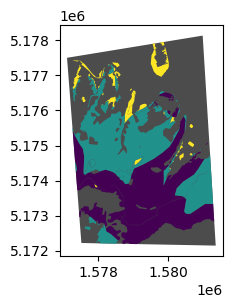

C:\Users\dav\AppData\Local\Temp\ipykernel_16804\3112525302.py:29: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  prio_option_aoi.plot(ax=ax, column='PixelScore', label='Prioritisation Option')


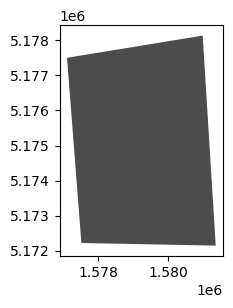

Saved:  Client_Outputs/A03_NativeVegetationProximity_20240829_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A03_NativeVegetationProximity_20240829_DUMMY.geotiff
Saved:  Client_Outputs/A03_NativeVegetationProximity_20240829_DUMMY.geotiff


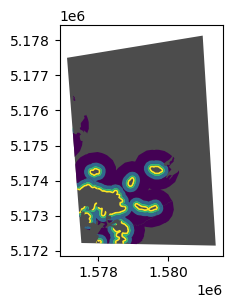

Saved:  Client_Outputs/A04_LegalProtection_20240829_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A04_LegalProtection_20240829_DUMMY.geotiff
Saved:  Client_Outputs/A04_LegalProtection_20240829_DUMMY.geotiff


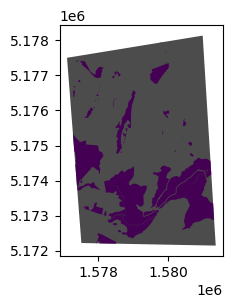

Saved:  Client_Outputs/A05_RelativeAfforability_20240829_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A05_RelativeAfforability_20240829_DUMMY.geotiff
Saved:  Client_Outputs/A05_RelativeAfforability_20240829_DUMMY.geotiff


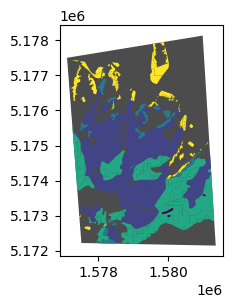

Saved:  Client_Outputs/A06_RiparianBenefit_20240829_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A06_RiparianBenefit_20240829_DUMMY.geotiff
Saved:  Client_Outputs/A06_RiparianBenefit_20240829_DUMMY.geotiff


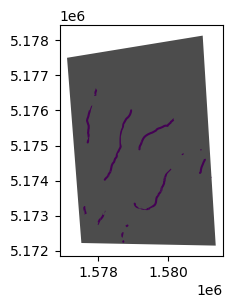

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\pyogrio\geopandas.py:261: UserWarning: More than one layer found in 'A07_NativeVegetationShapeImprovement_20240906.gpkg': '07_NativeVegetationShapeImprovement_20240906' (default), 'A07_NativeVegetationShapeImprovement_20240906'. Specify layer parameter to avoid this warning.
  result = read_func(


Saved:  Client_Outputs/A07_NativeVegetationShapeImprovement_20240906_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A07_NativeVegetationShapeImprovement_20240906_DUMMY.geotiff
Saved:  Client_Outputs/A07_NativeVegetationShapeImprovement_20240906_DUMMY.geotiff


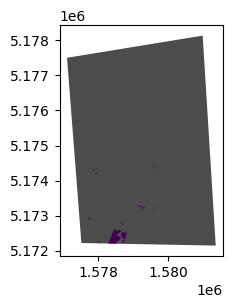

Saved:  Client_Outputs/A08_ProtectiveBuffer_20240828_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A08_ProtectiveBuffer_20240828_DUMMY.geotiff
Saved:  Client_Outputs/A08_ProtectiveBuffer_20240828_DUMMY.geotiff


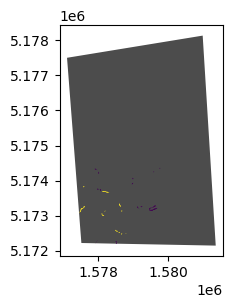

Saved:  Client_Outputs/A09_LandStability_20240829_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A09_LandStability_20240829_DUMMY.geotiff
Saved:  Client_Outputs/A09_LandStability_20240829_DUMMY.geotiff


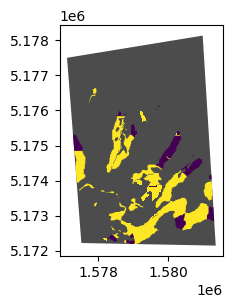

Saved:  Client_Outputs/A10_Ecosystem15percCoverGoal_20240829_DUMMY.gpkg
Raster saved and pyramids built at: Client_Outputs/A10_Ecosystem15percCoverGoal_20240829_DUMMY.geotiff
Saved:  Client_Outputs/A10_Ecosystem15percCoverGoal_20240829_DUMMY.geotiff


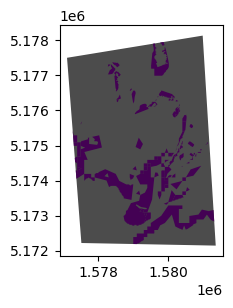

In [9]:
client_prio_option_paths = []
client_prio_option_paths_rast = []

for prio_option_path in prio_option_gpkg_file_paths:
    # New paths
    new_path = f"Client_Outputs/{Path(prio_option_path).stem}_{client_suffix}.gpkg"
    new_path_rast = f"Client_Outputs/{Path(prio_option_path).stem}_{client_suffix}.geotiff"
    client_prio_option_paths.append(new_path)
    client_prio_option_paths_rast.append(new_path_rast)

    # Read
    prio_option = gpd.read_file(f"{directory}{prio_option_path}")
    prio_option.sindex

    # Crop
    prio_option_aoi = prio_option.overlay(aoi[['geometry']])
    prio_option_aoi['Area_ha'] = (prio_option_aoi.area * m2_to_ha).round(4)

    # Save client version as vector and raster
    if prio_option_aoi.shape[0] > 0:
        prio_option_aoi.to_file(new_path)
        print('Saved: ', new_path)
        rasterize_and_save(aoi, prio_option_aoi, x_resolution, y_resolution, new_path_rast)
        print('Saved: ', new_path_rast)

    ### Optional: Visual inspection
    fig, ax = plt.subplots(figsize=(3, 3))
    aoi.plot(ax=ax, color='black', alpha=0.7, label='Area of Interest')
    prio_option_aoi.plot(ax=ax, column='PixelScore', label='Prioritisation Option')
    plt.show()

# Create Combined Raster

In [11]:
combined_output_path = f"Client_Outputs/A00_Navigator_All_Priotisation_Options_{client_suffix}.geotiff"
sum_prioritisation_option_geotiffs(client_prio_option_paths_rast, combined_output_path)

Adding file: Client_Outputs/A01_Threatened_Environment_20240624_DUMMY.geotiff
File not found: Client_Outputs/A02_Connectivity_20240916_DUMMY.geotiff. This should only happen if there were no polygons
                       for this Prioritisation Oprtion within the area of interest. Continuing to next file.
Adding file: Client_Outputs/A03_NativeVegetationProximity_20240829_DUMMY.geotiff
Adding file: Client_Outputs/A04_LegalProtection_20240829_DUMMY.geotiff
Adding file: Client_Outputs/A05_RelativeAfforability_20240829_DUMMY.geotiff
Adding file: Client_Outputs/A06_RiparianBenefit_20240829_DUMMY.geotiff
Adding file: Client_Outputs/A07_NativeVegetationShapeImprovement_20240906_DUMMY.geotiff
Adding file: Client_Outputs/A08_ProtectiveBuffer_20240828_DUMMY.geotiff
Adding file: Client_Outputs/A09_LandStability_20240829_DUMMY.geotiff
Adding file: Client_Outputs/A10_Ecosystem15percCoverGoal_20240829_DUMMY.geotiff


# Create Combined Vector file For NavigatorX
This is a very slow part of the process as it requires breaking each geotiff into small 'chunks' of area and then overlaying with all other Prioritisation options for that chunk

#### Create chunks

In [19]:
file_short_names = [
    'threatenv',
    'connect',
    'vegprox',
    'legalprot',
    'relaff',
    'ripben',
    'shapeopt',
    'protbuff',
    'landstaf',
    'covergoal'
]
file_short_mapping = {name: short for short, name in zip(file_short_names, sorted(client_prio_option_paths_rast))}
file_short_mapping

max_index = process_and_save_chunks(client_prio_option_paths_rast, 
                                    file_short_mapping, 
                                    'Client_Outputs/chunks', 
                                    chunk_size=256)
print(max_index)

Processing:  Client_Outputs/A01_Threatened_Environment_20240624_DUMMY.geotiff
Skipping missing file:  Client_Outputs/A02_Connectivity_20240916_DUMMY.geotiff
Processing:  Client_Outputs/A03_NativeVegetationProximity_20240829_DUMMY.geotiff
Processing:  Client_Outputs/A04_LegalProtection_20240829_DUMMY.geotiff
Processing:  Client_Outputs/A05_RelativeAfforability_20240829_DUMMY.geotiff
Processing:  Client_Outputs/A06_RiparianBenefit_20240829_DUMMY.geotiff
Processing:  Client_Outputs/A07_NativeVegetationShapeImprovement_20240906_DUMMY.geotiff
Processing:  Client_Outputs/A08_ProtectiveBuffer_20240828_DUMMY.geotiff
Processing:  Client_Outputs/A09_LandStability_20240829_DUMMY.geotiff
Processing:  Client_Outputs/A10_Ecosystem15percCoverGoal_20240829_DUMMY.geotiff
5


#### Combine Chunks

In [30]:
tolerance = 1
overlay_chunks(client_prio_option_paths_rast, 
               file_short_mapping, max_index, tolerance,  
               'Client_Outputs/chunks', 'Client_Outputs/chunks_stacked')
combined_gdf = combine_overlaid_chunks('Client_Outputs/chunks_stacked')

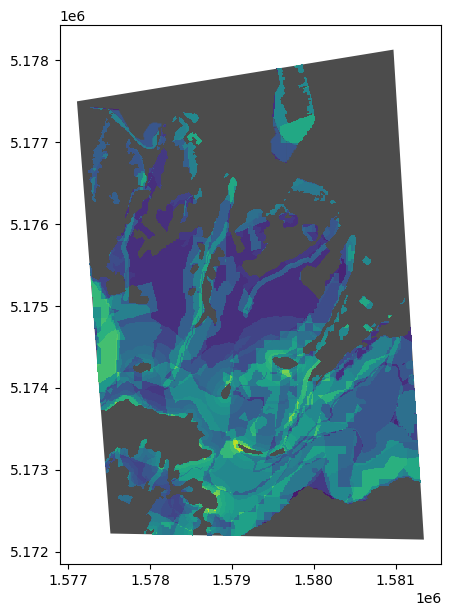

In [31]:
### Optional: Visual inspection
fig, ax = plt.subplots(figsize=(7, 7))
aoi.plot(ax=ax, color='black', alpha=0.7, label='Area of Interest')
combined_gdf.plot(ax=ax, column='PixelScore', label='Prioritisation Option')
plt.show()

In [32]:
combined_output_path_gpkg = f"Client_Outputs/A00_Navigator_All_Priotisation_Options_{client_suffix}.gpkg"
combined_output_path_gpkg_navx = f"Client_Outputs/A00_Navigator_All_Priotisation_Options_{client_suffix}_4326.geojson"
combined_gdf.to_file(combined_output_path_gpkg)
combined_gdf.to_crs('EPSG:4326').to_file(combined_output_path_gpkg_navx)